# 回测结果分析面板

这份 notebook 用于**结果分析**，默认读取导出的回测结果文件，重点看：

- 绩效摘要  
- 资产相关性矩阵
- 历史风险贡献度
- 净值与回撤  
- 年度收益  
- 月度收益热力图  
- 调仓次数与换手  
- 各资产平均权重与最后权重


In [ ]:

from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXPORT_DIR = Path("data/exports_risk_parity")

nav_df = pd.read_csv(EXPORT_DIR / "nav.csv", index_col=0, parse_dates=True)
weights_df = pd.read_csv(EXPORT_DIR / "weights.csv", index_col=0, parse_dates=True)
positions_df = pd.read_csv(EXPORT_DIR / "positions.csv", index_col=0, parse_dates=True)
target_weights_df = pd.read_csv(EXPORT_DIR / "target_weights.csv", index_col=0, parse_dates=True)
trades_df = pd.read_csv(EXPORT_DIR / "trades.csv")
rebalance_log_df = pd.read_csv(EXPORT_DIR / "rebalance_log.csv")
summary = pd.read_csv(EXPORT_DIR / "summary.csv", index_col=0)

asset_corr_matrix = pd.read_csv(
    EXPORT_DIR / "asset_corr_matrix.csv", 
    index_col=0
    )
risk_contribution_df = pd.read_csv(
    EXPORT_DIR / "risk_contribution_df.csv", 
    index_col=0, 
    parse_dates=True  # 核心：让 Pandas 把 Index 重新识别为时间格式
    )


plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

print("files loaded")
display(summary)


files loaded


,0
total_return,0.286548
annual_return,0.085035
excess_return,0.085035
annual_volatility,0.074278
sharpe_ratio,1.134652
max_drawdown,-0.067807
calmar_ratio,-1.254075
avg_asset_correlation,0.076482


,159981.SZ,159985.SZ,501018.SH,510300.SH,511090.SH,515100.SH,518880.SH
ts_code,,,,,,,
159981.SZ,1.000000,0.202517,0.503084,0.246324,-0.161805,0.131240,0.007576
159985.SZ,0.202517,1.000000,0.149922,0.061202,0.006707,0.039914,-0.007446
501018.SH,0.503084,0.149922,1.000000,0.071223,-0.066138,0.096788,0.073554
510300.SH,0.246324,0.061202,0.071223,1.000000,-0.317795,0.442973,0.172953
511090.SH,-0.161805,0.006707,-0.066138,-0.317795,1.000000,-0.171053,0.000148
515100.SH,0.131240,0.039914,0.096788,0.442973,-0.171053,1.000000,0.124230
518880.SH,0.007576,-0.007446,0.073554,0.172953,0.000148,0.124230,1.000000


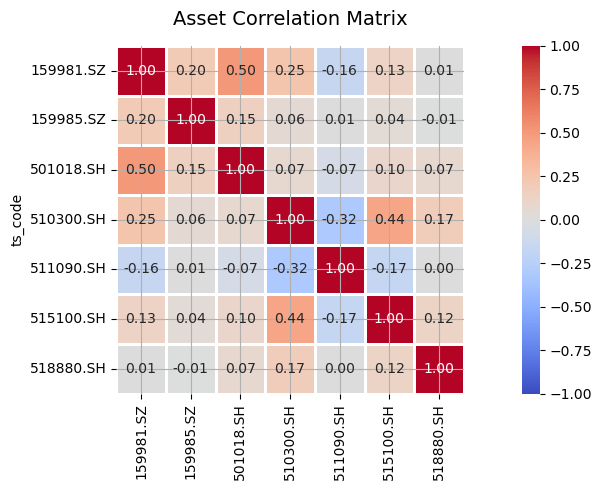

In [42]:
# ========= 资产相关性矩阵 =========
# plt.figure(figsize=(8, 6))
# 使用 coolwarm 色系：红代表高度正相关，蓝代表负相关
sns.heatmap(
    asset_corr_matrix, 
    annot=True,        # 在格子里显示具体数值
    cmap='coolwarm',   # 冷暖色调
    vmin=-1, vmax=1,   # 相关性系数的理论极值
    center=0,          # 0 设为中间色（通常是白色或浅灰色）
    fmt='.2f',         # 保留两位小数
    linewidths=1,      # 格子之间的间距线
    square=True        # 保持格子是正方形
)
display(asset_corr_matrix)
plt.title('Asset Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


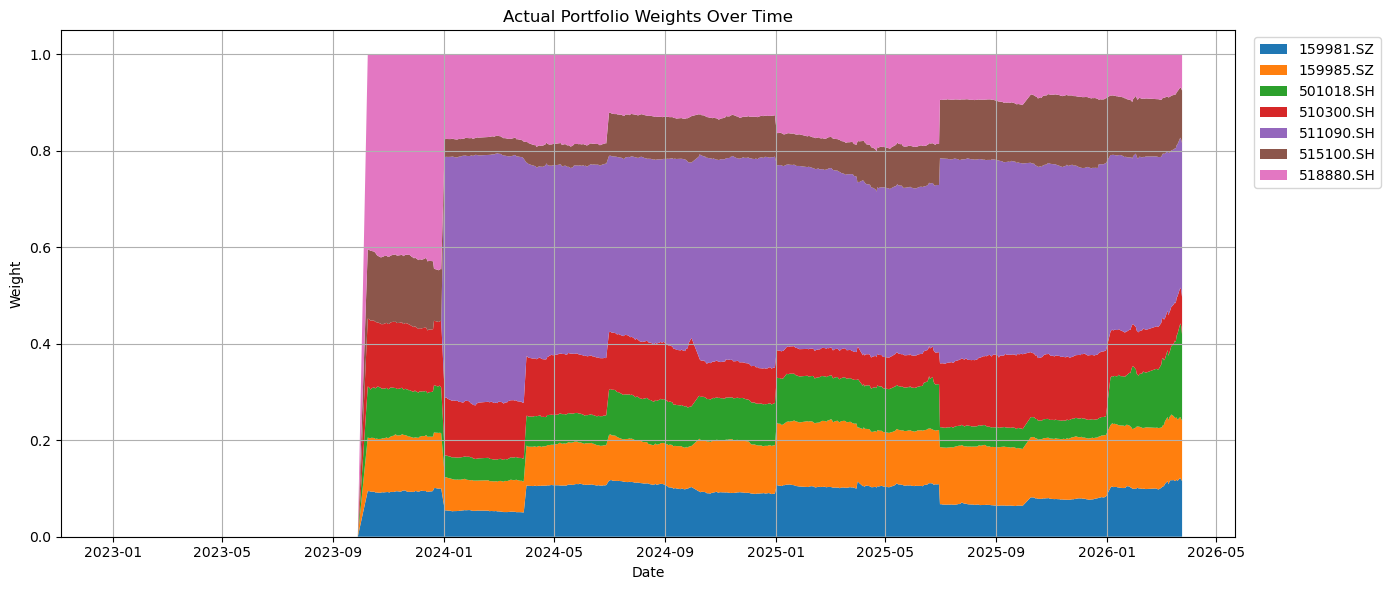

In [50]:
# ========= 实际持有比例变化 =========
actual_weights_plot = weights_df.copy().fillna(0.0)

plt.figure(figsize=(14, 6))
plt.stackplot(
    actual_weights_plot.index,
    actual_weights_plot.T.values,
    labels=actual_weights_plot.columns
)
plt.title("Actual Portfolio Weights Over Time")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

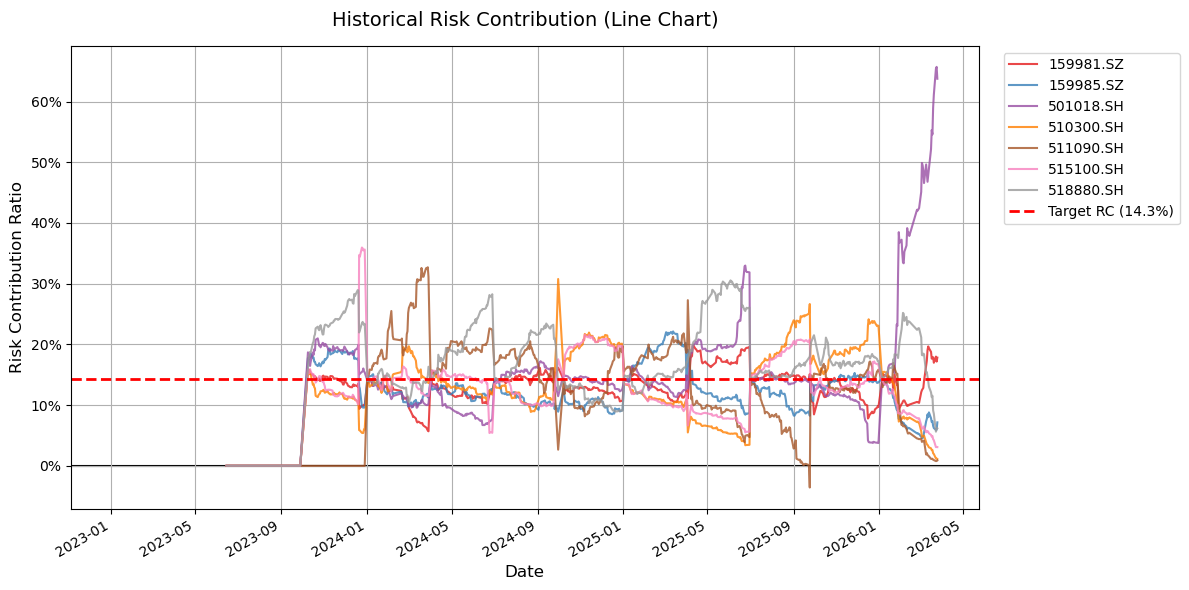

In [43]:
import matplotlib.ticker as ticker
# 创建画布
fig, ax = plt.subplots(figsize=(12, 6))

# 直接画折线图，而不是面积图
risk_contribution_df.plot.line(
    ax=ax, 
    linewidth=1.5, 
    alpha=0.8,
    colormap='Set1' # 使用对比度高的色系
)

# 1. 画一条 0 轴的黑色实线，用来捕捉负风险贡献
plt.axhline(0, color='black', linewidth=1.5, linestyle='-', zorder=1)

# 2. 画一条“目标风险平价线”的红色虚线
num_assets = len(risk_contribution_df.columns)
target_ratio = 1.0 / num_assets
plt.axhline(target_ratio, color='red', linewidth=2, linestyle='--', 
            label=f'Target RC ({target_ratio:.1%})', zorder=2)

plt.title('Historical Risk Contribution (Line Chart)', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Risk Contribution Ratio', fontsize=12)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

# 调整图例
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

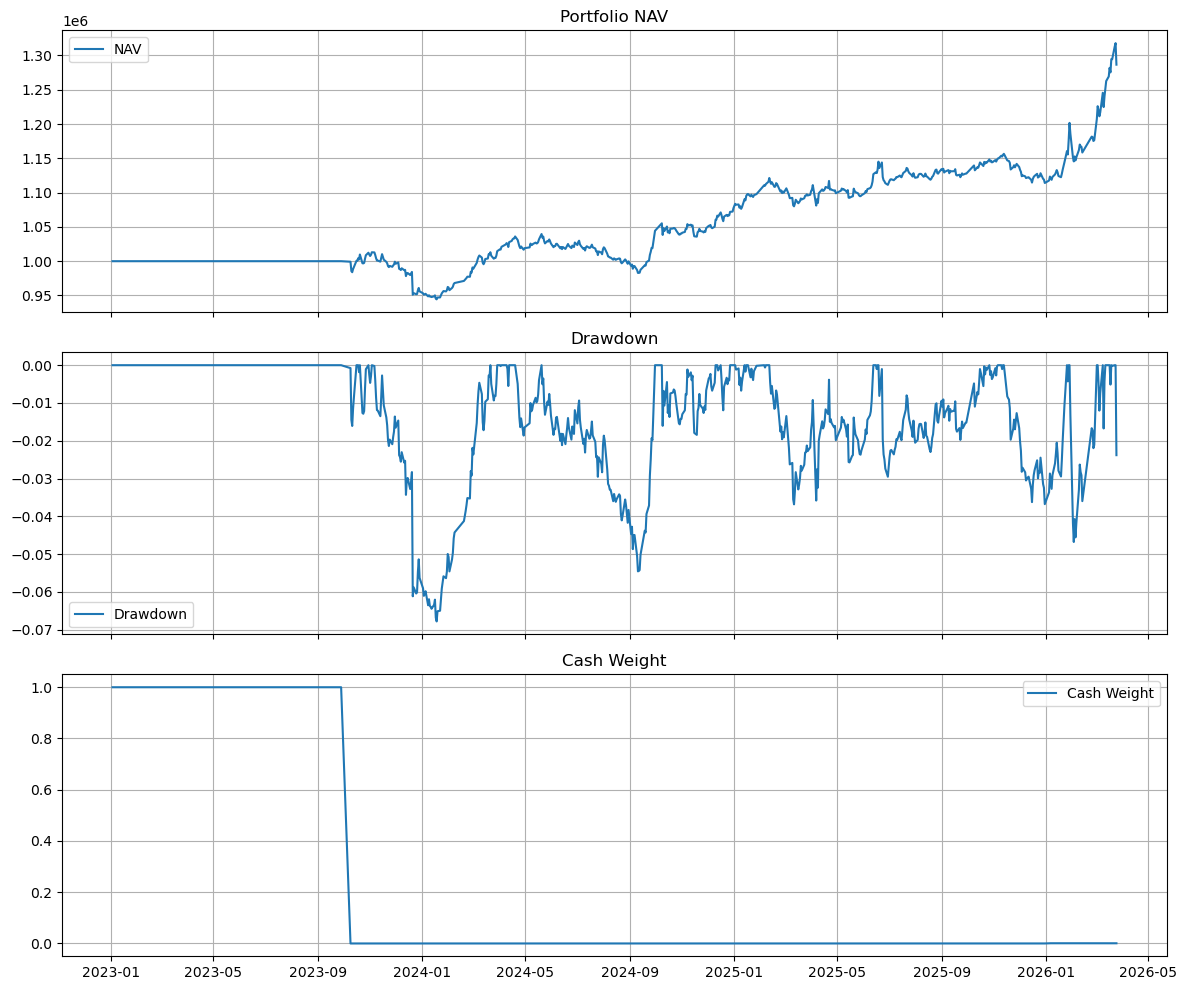

平均现金占比： 0.2337
最大现金占比： 1.0
最近现金占比： 0.0007


In [44]:
# ========= 基础序列 =========
nav = nav_df["nav"].copy()
cash_weight = nav_df["cash"] / nav_df["nav"]
daily_ret = nav.pct_change().fillna(0.0)
drawdown = nav / nav.cummax() - 1.0

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. 净值
axes[0].plot(nav.index, nav, label="NAV")
axes[0].set_title("Portfolio NAV")
axes[0].legend()

# 2. 回撤
axes[1].plot(drawdown.index, drawdown, label="Drawdown")
axes[1].set_title("Drawdown")
axes[1].legend()

# 3. 现金占比
axes[2].plot(cash_weight.index, cash_weight, label="Cash Weight")
axes[2].set_title("Cash Weight")
axes[2].legend()

plt.tight_layout()
plt.show()

print("平均现金占比：", round(cash_weight.mean(), 4))
print("最大现金占比：", round(cash_weight.max(), 4))
print("最近现金占比：", round(cash_weight.iloc[-1], 4))

C:\Users\12178\AppData\Local\Temp\ipykernel_37844\881751147.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  year_end_nav = nav.resample("Y").last()


,annual_return
trade_date,
2023,NaN
2024,0.127030
2025,0.033923
2026,0.154902


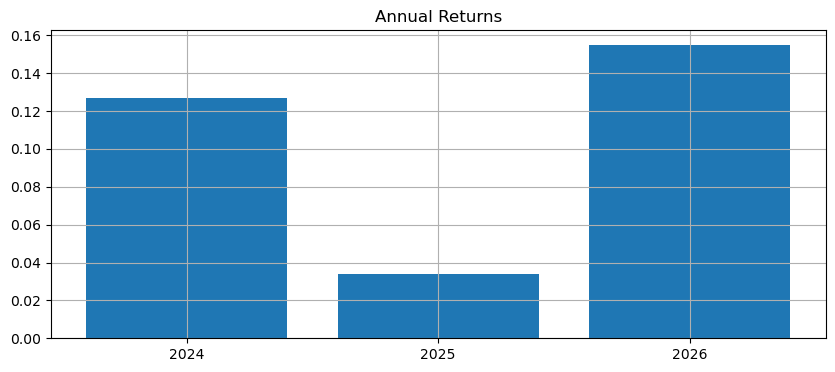

In [45]:

# ========= 年度收益 =========
year_end_nav = nav.resample("Y").last()
annual_returns = year_end_nav.pct_change()
annual_returns.index = annual_returns.index.year

annual_returns_df = annual_returns.to_frame("annual_return")
display(annual_returns_df)

plt.figure(figsize=(10, 4))
plt.bar(annual_returns_df.index.astype(str), annual_returns_df["annual_return"])
plt.title("Annual Returns")
plt.show()


C:\Users\12178\AppData\Local\Temp\ipykernel_37844\561823234.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_end_nav = nav.resample("M").last()


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,nan%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.97%,-1.04%,-4.33%
2024,0.67%,2.96%,2.40%,0.43%,0.67%,0.14%,-0.94%,-1.75%,4.46%,-0.39%,0.76%,2.79%
2025,1.89%,0.19%,-0.27%,0.19%,-0.28%,1.40%,1.14%,0.52%,-0.18%,1.50%,-0.24%,-2.44%
2026,6.46%,-0.81%,9.37%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%


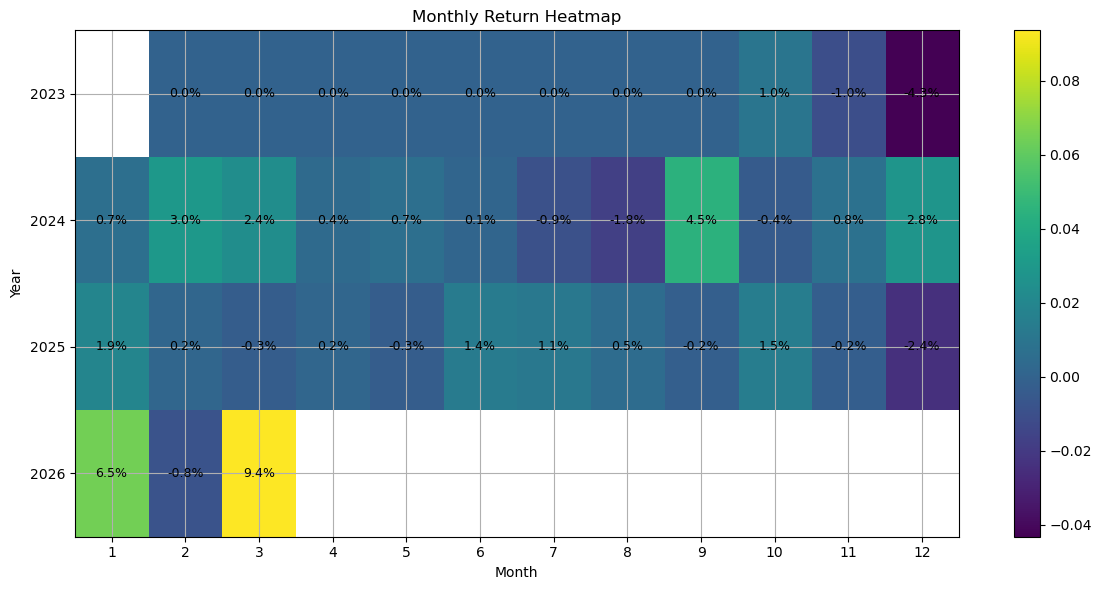

In [46]:

# ========= 月度收益热力图（表格版） =========
month_end_nav = nav.resample("M").last()
monthly_returns = month_end_nav.pct_change()
monthly_df = monthly_returns.to_frame("monthly_return")
monthly_df["year"] = monthly_df.index.year
monthly_df["month"] = monthly_df.index.month

heatmap_table = monthly_df.pivot(index="year", columns="month", values="monthly_return")
display(heatmap_table.style.format("{:.2%}"))
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heatmap_table.values, aspect="auto")

ax.set_xticks(range(len(heatmap_table.columns)))
ax.set_xticklabels(heatmap_table.columns)

ax.set_yticks(range(len(heatmap_table.index)))
ax.set_yticklabels(heatmap_table.index)

ax.set_title("Monthly Return Heatmap")
ax.set_xlabel("Month")
ax.set_ylabel("Year")

for i in range(heatmap_table.shape[0]):
    for j in range(heatmap_table.shape[1]):
        val = heatmap_table.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.1%}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


In [47]:

# ========= 调仓统计 =========
if len(rebalance_log_df) > 0:
    rebalance_log_df["trade_date"] = pd.to_datetime(rebalance_log_df["trade_date"])
    rebalance_log_df["year"] = rebalance_log_df["trade_date"].dt.year

    print("调仓日志：")
    display(rebalance_log_df.tail(20))

    yearly_rebalance_count = rebalance_log_df.groupby("year").size().rename("rebalance_count")
    yearly_turnover = rebalance_log_df.groupby("year")["turnover"].sum().rename("turnover_sum")

    display(pd.concat([yearly_rebalance_count, yearly_turnover], axis=1))
else:
    print("没有调仓记录")


调仓日志：


,signal_date,trade_date,reason,drift_value,turnover,cash_after_trade,traded,trade_count,year
0,2023-09-28,2023-10-09,schedule,NaN,1.000000,0.425088,1,3964,2023
1,2023-12-29,2024-01-02,schedule,NaN,0.997530,60.291163,1,52,2024
2,2024-03-29,2024-04-01,schedule,NaN,0.201224,94.260875,1,617,2024
3,2024-06-28,2024-07-01,schedule,NaN,0.195677,28.780588,1,705,2024
4,2024-09-30,2024-10-08,schedule,NaN,0.170006,21.260125,1,241,2024
5,2024-12-31,2025-01-02,schedule,NaN,0.175174,58.393988,1,425,2025
6,2025-03-31,2025-04-01,schedule,NaN,0.097750,98.255325,1,341,2025
7,2025-06-30,2025-07-01,schedule,NaN,0.373238,92.265413,1,497,2025
8,2025-09-30,2025-10-09,schedule,NaN,0.092839,62.449125,1,367,2025
9,2025-12-31,2026-01-05,schedule,NaN,0.164228,960.337550,1,797,2026


,rebalance_count,turnover_sum
year,,
2023,1,1.000000
2024,4,1.564437
2025,4,0.739002
2026,1,0.164228


In [48]:

# ========= 交易统计 =========
if len(trades_df) > 0:
    trade_summary = trades_df.groupby(["ts_code", "side"])["trade_value"].agg(["count", "sum"])
    display(trade_summary)

    fee_summary = trades_df.groupby("side")["cost"].sum().rename("total_cost")
    display(fee_summary)
else:
    print("没有交易记录")


count         sum
ts_code   side                   
159981.SZ BUY    1595  242429.500
          SELL      3  102273.350
159985.SZ BUY    1051  219104.400
          SELL      2   63508.125
501018.SH BUY    1891  238666.375
          SELL      2  106803.800
510300.SH BUY     608  232807.075
          SELL      5  172552.300
511090.SH BUY      61  666868.325
          SELL      6  292926.225
515100.SH BUY    1789  283323.600
          SELL      4  111735.675
518880.SH BUY     982  442769.325
          SELL      7  478956.825

side
BUY     1162.98430
SELL     664.37815
Name: total_cost, dtype: float64

最后一期实际权重：


,last_weight
511090.SH,0.319281
501018.SH,0.178034
159985.SZ,0.124518
159981.SZ,0.116172
515100.SH,0.109358
510300.SH,0.077703
518880.SH,0.074188


样本期平均实际权重：


,avg_weight
511090.SH,0.274761
518880.SH,0.127843
159985.SZ,0.082489
510300.SH,0.081475
515100.SH,0.071180
159981.SZ,0.069871
501018.SH,0.058657


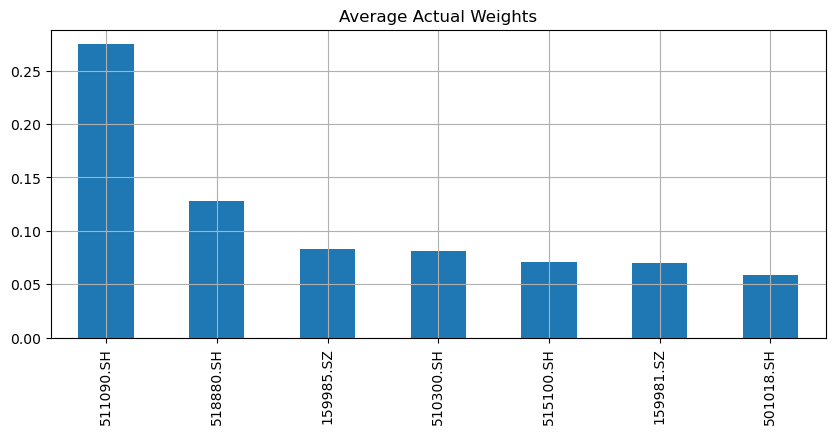

In [49]:

# ========= 权重分析 =========
print("最后一期实际权重：")
display(weights_df.tail(1).T.rename(columns={weights_df.index[-1]: "last_weight"}).sort_values("last_weight", ascending=False))

print("样本期平均实际权重：")
avg_weight = weights_df.mean().sort_values(ascending=False).to_frame("avg_weight")
display(avg_weight)

plt.figure(figsize=(10, 4))
avg_weight["avg_weight"].plot(kind="bar")
plt.title("Average Actual Weights")
plt.show()


In [51]:

# ========= 最近持仓与目标权重对比 =========
if len(weights_df) > 0 and len(target_weights_df) > 0:
    last_actual = weights_df.tail(1).T.rename(columns={weights_df.index[-1]: "actual_weight"})
    last_target = target_weights_df.tail(1).T.rename(columns={target_weights_df.index[-1]: "target_weight"})
    compare = last_actual.join(last_target, how="outer").fillna(0.0)
    compare["diff"] = compare["actual_weight"] - compare["target_weight"]
    display(compare.sort_values("target_weight", ascending=False))


,actual_weight,target_weight,diff
511090.SH,0.319281,0.471965,-0.152684
510300.SH,0.077703,0.138253,-0.060551
515100.SH,0.109358,0.131709,-0.022351
159985.SZ,0.124518,0.117959,0.006558
159981.SZ,0.116172,0.060559,0.055613
518880.SH,0.074188,0.043750,0.030438
501018.SH,0.178034,0.035804,0.142230


In [52]:

# ========= 核心结论快照 =========
snapshot = {
    "summary": summary,
    "last_nav": nav.iloc[-1],
    "max_drawdown": drawdown.min(),
    "last_positions": positions_df.tail(1).T if len(positions_df) > 0 else None,
    "last_weights": weights_df.tail(1).T if len(weights_df) > 0 else None,
    "rebalance_count": len(rebalance_log_df),
    "trade_count": len(trades_df),
}

snapshot["summary"]


,0
total_return,0.286548
annual_return,0.085035
excess_return,0.085035
annual_volatility,0.074278
sharpe_ratio,1.134652
max_drawdown,-0.067807
calmar_ratio,-1.254075
avg_asset_correlation,0.076482
